# PD macro scenarios

A separate macroeconomic satellite adjusts the loan-level monthly hazard under Base, Upside and Downside paths.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"
CFG = yaml.safe_load((ROOT / "config" / "project.yaml").read_text())

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

The satellite models monthly hazard log-odds residuals. Unemployment and the negative of GDP and HPI growth are constrained to non-negative coefficients. The production result is a monthly scenario term structure, not one lifetime percentage.

In [2]:
query('select * from pd_macro_satellite_metrics')

,sample,months,defaults,mae_log_odds,r_squared,validation_design,variable,coefficient,validation_status,production_role
0,development,99.0000,570.0000,0.6413,-0.0000,chronological monthly aggregate split,None,NaN,limited: weak out-of-time evidence; used as co...,economically constrained PD scenario satellite
1,out_of_time,23.0000,24.0000,0.5902,-0.1927,chronological monthly aggregate split,None,NaN,limited: weak out-of-time evidence; used as co...,economically constrained PD scenario satellite
2,coefficient,NaN,NaN,NaN,NaN,None,unemployment_rate,0.1512,limited: weak out-of-time evidence; used as co...,economically constrained PD scenario satellite
3,coefficient,NaN,NaN,NaN,NaN,None,weak_gdp_growth,0.0000,limited: weak out-of-time evidence; used as co...,economically constrained PD scenario satellite
4,coefficient,NaN,NaN,NaN,NaN,None,weak_hpi_growth,0.0000,limited: weak out-of-time evidence; used as co...,economically constrained PD scenario satellite


In [3]:
satellite = joblib.load(ROOT / 'outputs' / 'models' / 'pd_macro_satellite.joblib')
ridge = satellite.model.named_steps['ridge']
pd.DataFrame({'variable':['unemployment_rate','weak_gdp_growth','weak_hpi_growth'],
              'coefficient':ridge.coef_})

,variable,coefficient
0,unemployment_rate,0.1512
1,weak_gdp_growth,0.0000
2,weak_hpi_growth,0.0000


In [4]:
macro = query("select * from macro_scenarios where month_number<=60"); macro.head()

,scenario,scenario_weight,month_number,period,unemployment_rate,gdp_growth_yoy,hpi_growth_yoy,mortgage_rate,scenario_is_official_forecast,hpi_factor
0,Base,0.5152,1,2026-04-01,4.3918,1.9990,2.0293,3.9900,0,1.0017
1,Base,0.5152,2,2026-05-01,4.3838,2.0084,2.1364,3.9900,0,1.0034
2,Base,0.5152,3,2026-06-01,4.3760,2.0175,2.2405,3.9900,0,1.0053
3,Base,0.5152,4,2026-07-01,4.3685,2.0264,2.3418,3.9900,0,1.0072
4,Base,0.5152,5,2026-08-01,4.3611,2.0350,2.4403,3.9900,0,1.0093


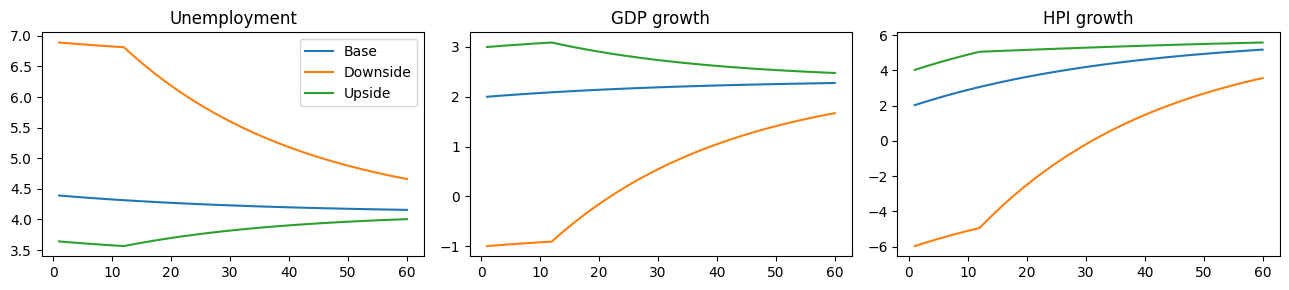

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for name, data in macro.groupby('scenario'):
    axes[0].plot(data.month_number, data.unemployment_rate, label=name)
    axes[1].plot(data.month_number, data.gdp_growth_yoy, label=name)
    axes[2].plot(data.month_number, data.hpi_growth_yoy, label=name)
axes[0].set_title('Unemployment'); axes[1].set_title('GDP growth'); axes[2].set_title('HPI growth')
axes[0].legend(); plt.tight_layout()

Text(0.5, 1.0, 'Stage 2 PD scenarios')

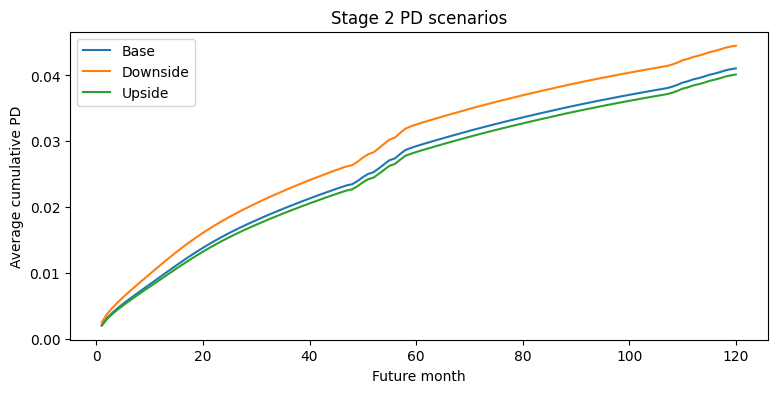

In [6]:
pd_scen = query("select * from pd_term_structure where stage=2 and future_month<=120")
for name, data in pd_scen.groupby('scenario'):
    plt.plot(data.future_month, data.cumulative_pd, label=name)
plt.xlabel('Future month'); plt.ylabel('Average cumulative PD'); plt.legend(); plt.title('Stage 2 PD scenarios')

Output: conditional, survival, marginal and cumulative PD by loan, scenario and month.